<a href="https://colab.research.google.com/github/deepakk7195/IISC_CDS_DS/blob/Big-Data/MiniProject_4_End_to_End_Analytics_Pyspark_Stan_Ver_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advanced Certification Program in Computational Data Science
## A program by IISc and TalentSprint
### Mini-Project: End-to-end analytics application using Pyspark

## Problem Statement

Perform sentiment classification by analyzing the tweets data with Pyspark

## Learning Objectives

At the end of the mini-project, you will be able to :

* analyze the text data using pyspark
* derive the insights and visualize the data
* implement feature extraction and classify the data
* train the classification model and deploy

### Dataset

The dataset chosen for this mini-project is **[Twitter US Airline Sentiment](https://data.world/socialmediadata/twitter-us-airline-sentiment)**. It is a record of tweets about airlines in the US. It was created by scraping Twitter data from February 2015. Contributors were asked to first classify positive, negative, and neutral tweets, followed by categorizing negative reasons (such as "late flight" or "rude service").  Along with other information, it contains ID of a Tweet, the sentiment of a tweet ( neutral, negative and positive), reason for a negative tweet, name of airline and text of a tweet.

## Information

The airline industry is a very competitive market that has grown rapidly in the past 2 decades. Airline companies resort to traditional customer feedback forms which in turn are very tedious and time consuming. This is where Twitter data serves as a good source to gather customer feedback tweets and perform sentiment analysis. This dataset comprises of tweets for 6 major US Airlines and a multi-class classification can be performed to categorize the sentiment (neutral, negative, positive). For this mini-project we will start with pre-processing techniques to clean the tweets and then represent these tweets as vectors. A classification algorithm will be used to predict the sentiment for unseen tweets data. The end-to-end analytics will be performed using Pyspark.

## Grading = 10 Points

Install Spark

In [ ]:
# install java
!apt-get install openjdk-8-jdk-headless -qq > /dev/null

# install spark (change the version number if needed)
!wget -q https://archive.apache.org/dist/spark/spark-3.0.0/spark-3.0.0-bin-hadoop3.2.tgz

# unzip the spark file to the current folder
!tar xf spark-3.0.0-bin-hadoop3.2.tgz

**Note: The above code cell will take around 8 mins 30 secs for execution.**


### Set the os environment

In [ ]:
# set your spark folder to your system path environment.
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.0.0-bin-hadoop3.2"

### Install findspark

In [ ]:
# install findspark using pip
!pip install -q findspark

#### Install Pyspark

In [ ]:
#@title Install packages and download the dataset
!pip -qq install pyspark
!pip -qq install handyspark
!wget -qq https://cdn.iisc.talentsprint.com/CDS/MiniProjects/US_Airline_Tweets.csv
print("Packages installed successfully and dataset downloaded!!")

Packages installed successfully and dataset downloaded!!


In [ ]:
#from handyspark import *
import findspark
findspark.init()

### Install numpy==1.23.1

In [ ]:
!pip -qq install mxnet-mkl==1.6.0 numpy==1.23.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 MB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.0/17.0 MB 46.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
albucore 0.0.16 requires numpy>=1.24, but you have numpy 1.23.1 which is incompatible.
albumentations 1.4.15 requires numpy>=1.24.4, but you have numpy 1.23.1 which is incompatible.
bigframes 1.22.0 requires numpy>=1.24.0, but you have numpy 1.23.1 which is incompatible.
chex 0.1.87 requires numpy>=1.24.1, but you have numpy 1.23.1 which is incompatible.
ibis-framework 9.2.0 requires numpy<3,>=1.23.2, but you have numpy 1.23.1 which is incompatible.
jax 0.4.33 requires numpy>=1.24, but you have numpy 1.23.1 which is incompatible.
jaxlib 0.4.33 requires numpy>=1.24, but you have numpy 1.23.1 which is incompatible.
pandas-stubs 2.2.2.240909 requires numpy>=1.23

In [ ]:
import numpy as np
np.bool = np.bool_

### Import Handyspark

In [ ]:
import handyspark

#### Import required packages

In [ ]:
import os
import numpy as np
import pandas as pd
# fixes issue with seaborn hiding fliers on boxplot
import matplotlib as mpl
%matplotlib inline

from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from handyspark import *
import seaborn as sns
from matplotlib import pyplot as plt
import re
import string
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.feature import CountVectorizer
from pyspark.ml.classification import NaiveBayes
from pyspark.sql.types import ArrayType, StringType
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# NLTK imports
import nltk
nltk.download('punkt')
# Download stopwords
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


### Data Loading

#### Start a Spark Session

Spark session is a combined entry point of a Spark application, which came into implementation from Spark 2.0. It provides a way to interact with various Spark functionalities, with a lesser number of constructs.

In [ ]:
# YOUR CODE HERE
# Start Spark session
spark = SparkSession.builder.appName("MP4-TweetAnalytics").getOrCreate()


#### Load the data and infer the schema

To load the dataset use the `read.csv` with `inferSchema` and `header` as parameters.

In [ ]:
path = "/content/US_Airline_Tweets.csv"
# YOUR CODE HERE
dfTweets = spark.read.csv(path, header=True, inferSchema= True)

### EDA & Visualization ( 2 points)

#### Visualize the horizontal barplot of airline_sentiment (positive, negative, neutral)

Convert the data to handyspark and remove the other records from the column except 3 values mentioned above and plot the graph

In [ ]:
# YOUR CODE HERE
# Convert the data to handyspark
dfTweetsHandy = HandyFrame(dfTweets)

In [ ]:
dfTweetsHandy.head()

Row(tweet_id='570306133677760513', airline_sentiment='neutral', airline_sentiment_confidence='1.0', negativereason=None, negativereason_confidence=None, airline='Virgin America', airline_sentiment_gold=None, name='cairdin', negativereason_gold=None, retweet_count=0, text='@VirginAmerica What @dhepburn said.', tweet_coord=None, tweet_created='2015-02-24 11:35:52 -0800', tweet_location=None, user_timezone='Eastern Time (US & Canada)')

In [ ]:
dfTweetsHandy.describe()

HandyFrame[summary: string, tweet_id: string, airline_sentiment: string, airline_sentiment_confidence: string, negativereason: string, negativereason_confidence: string, airline: string, airline_sentiment_gold: string, name: string, negativereason_gold: string, retweet_count: string, text: string, tweet_coord: string, tweet_created: string, tweet_location: string, user_timezone: string]

<Axes: ylabel='airline_sentiment'>

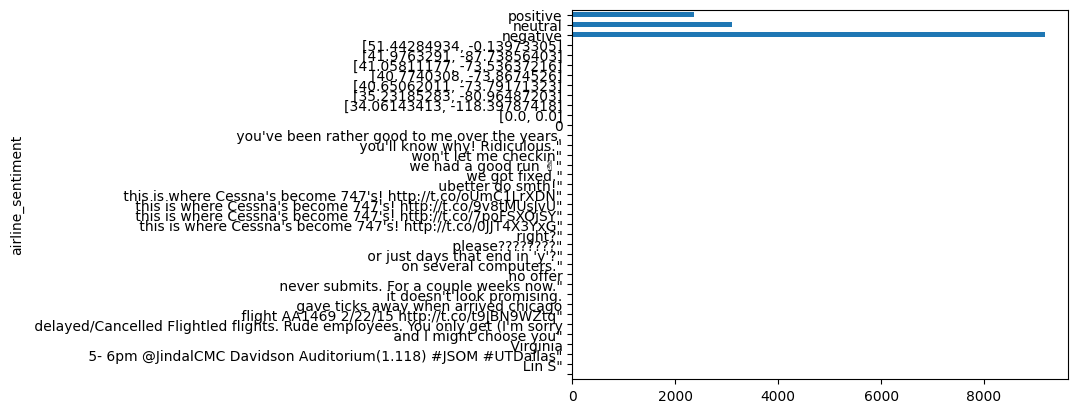

In [ ]:
dfTweetsHandy.cols['airline_sentiment'].value_counts().plot(kind='barh')

In [ ]:
filtered_df = dfTweetsHandy.filter((dfTweetsHandy['airline_sentiment'] == 'positive') |
                                   (dfTweetsHandy['airline_sentiment'] == 'negative') |
                                   (dfTweetsHandy['airline_sentiment'] == 'neutral'))

In [ ]:
# Group by airline_sentiment and count the occurrences of each value
sentiment_counts = filtered_df.groupby('airline_sentiment').count()

sentiment_counts.show()

+-----------------+-----+
|airline_sentiment|count|
+-----------------+-----+
|         positive| 2363|
|          neutral| 3099|
|         negative| 9178|
+-----------------+-----+



<Axes: >

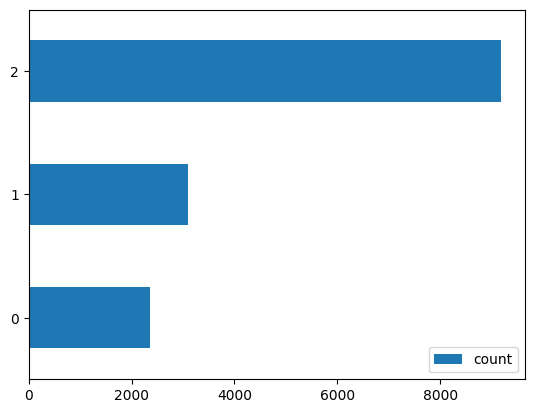

In [ ]:
sentiment_counts.toPandas().plot(kind='barh')

<Axes: >

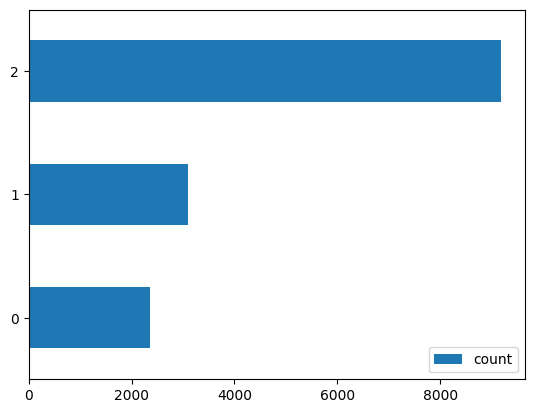

In [ ]:
sentiment_counts.toPandas().plot(kind='barh')

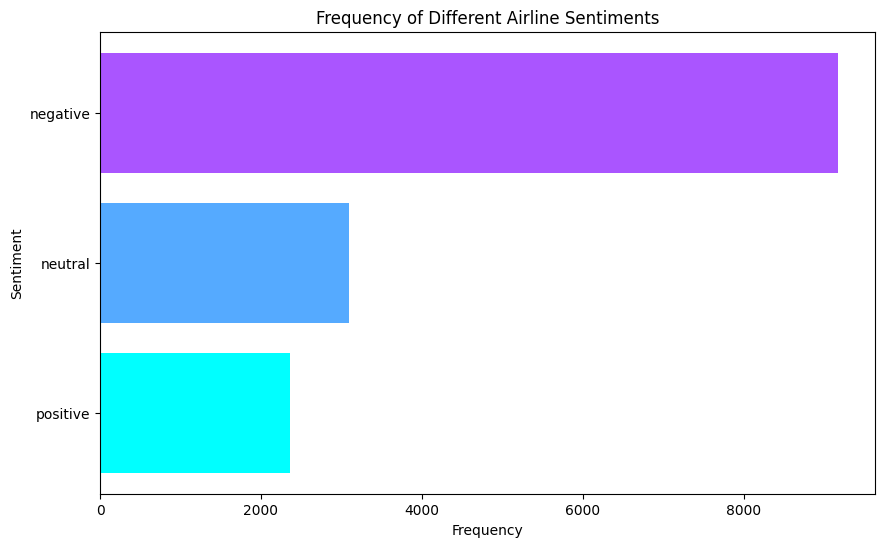

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Convert the HandySpark DataFrame to pandas DataFrame
sentiment_counts_pd = sentiment_counts.toPandas()

# Set the 'airline_sentiment' column as the index for better labeling
sentiment_counts_pd.set_index('airline_sentiment', inplace=True)

# Extract the sentiment labels and their counts
sentiments = sentiment_counts_pd.index
counts = sentiment_counts_pd['count']

# Create a colormap and generate different colors for each bar
cmap = cm.get_cmap('cool')  # You can choose other colormaps like 'plasma', 'cool', etc.
colors = [cmap(i / len(counts)) for i in range(len(counts))]

# Create the horizontal bar plot
plt.figure(figsize=(10, 6))
plt.barh(sentiments, counts, color=colors)
plt.xlabel('Frequency')
plt.ylabel('Sentiment')
plt.title('Frequency of Different Airline Sentiments')

# Display the plot
plt.show()


In [ ]:
dfTweetsHandy_pd = dfTweetsHandy.toPandas()
sentiment_list = dfTweetsHandy_pd['airline_sentiment'].tolist()
print(set(sentiment_list))



INFO: Safety is ON - returning up to 1000 instances.
{'positive', 'negative', ' this is where Cessna\'s become 747\'s! http://t.co/9v8tMUsJvU"', 'neutral', ' won\'t let me checkin"', None}


#### Plot the number of tweets received for each airline

In [ ]:
# YOUR CODE HERE
airline_counts = dfTweetsHandy.groupby('airline').count()
airline_counts.show()

+--------------------+-----+
|             airline|count|
+--------------------+-----+
|      Rossford, Ohio|    2|
|               Delta| 2222|
|               Quito|    1|
|                null|  179|
|2015-02-22 14:22:...|    1|
|      Virgin America|  504|
|ÜT: 40.96513,-73....|    1|
|              United| 3822|
|       Arlington, VA|    1|
|Eastern Time (US ...|    1|
|Pacific Time (US ...|    2|
|             Arizona|    1|
|          US Airways| 2913|
| Nashville Tennessee|    1|
|    Edmond, Oklahoma|    1|
|           Southwest| 2420|
|Atlantic Highland...|    1|
|             Tijuana|    5|
|            American| 2759|
+--------------------+-----+



In [ ]:
proper_airline_names = ('Delta', 'United', 'Virgin America', 'US Airways', 'Southwest', 'American')

In [ ]:
dfTweetsProperAirlines = dfTweetsHandy.filter(col('airline').isin(*proper_airline_names))

In [ ]:
airline_tweet_counts = dfTweetsProperAirlines.groupby('airline').count()
airline_tweet_counts.show()

+--------------+-----+
|       airline|count|
+--------------+-----+
|         Delta| 2222|
|Virgin America|  504|
|        United| 3822|
|    US Airways| 2913|
|     Southwest| 2420|
|      American| 2759|
+--------------+-----+



Text(0.5, 1.0, 'Tweet Count for Different Airlines')

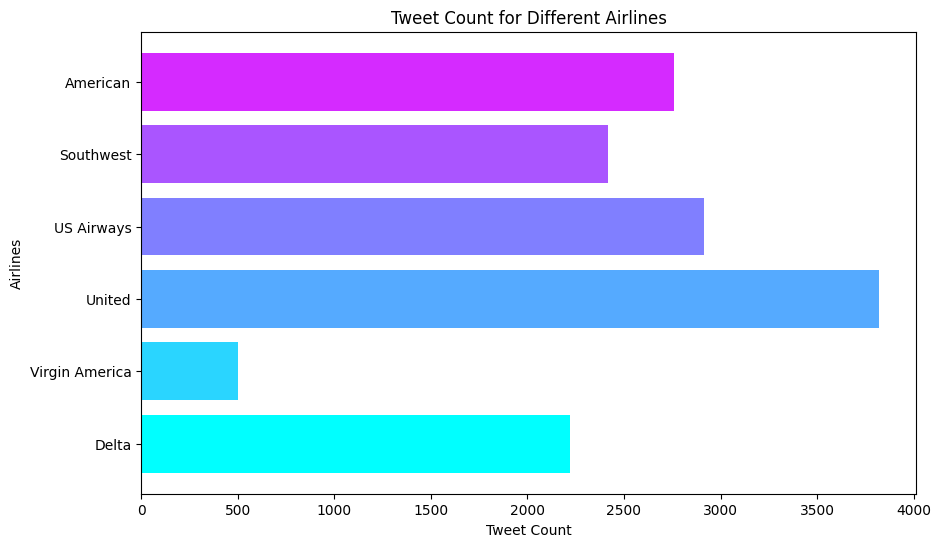

In [ ]:
# Convert the HandySpark DataFrame to pandas DataFrame
airline_tweet_counts_pd = airline_tweet_counts.toPandas()

# Set the 'airline' column as the index for better labeling
airline_tweet_counts_pd.set_index('airline', inplace=True)

# Extract the sentiment labels and their counts
airlines = airline_tweet_counts_pd.index
counts = airline_tweet_counts_pd['count']

# Create a colormap and generate different colors for each bar
cmap = cm.get_cmap('cool')  # You can choose other colormaps like 'plasma', 'cool', etc.
colors = [cmap(i / len(counts)) for i in range(len(counts))]

# Create the horizontal bar plot
plt.figure(figsize=(10, 6))
plt.barh(airlines, counts, color=colors)
plt.xlabel('Tweet Count')
plt.ylabel('Airlines')
plt.title('Tweet Count for Different Airlines')

#### Visualize a stacked barchart of 6 US airlines and 3 sentiments on each bar

* Group the sentiment counts for each airline. [hint](https://github.com/dvgodoy/handyspark#stratify)

* Display the count corresponding to each sentiment in each bar. [hint](https://cdn.iisc.talentsprint.com/CDS/MiniProjects/M5_NB_MiniProject_4_End_to_End_Analytics_Pyspark%20priteshbgohil_medium_com_stacked_bar_chart_in_python.pdf)

In [ ]:
# YOUR CODE HERE
airline_sentiment_counts = dfTweetsProperAirlines.groupby(['airline', 'airline_sentiment']).count()
airline_sentiment_counts.show()

+--------------+-----------------+-----+
|       airline|airline_sentiment|count|
+--------------+-----------------+-----+
|     Southwest|         negative| 1186|
|      American|         negative| 1960|
|Virgin America|          neutral|  171|
|    US Airways|          neutral|  381|
|        United|         positive|  492|
|    US Airways|         negative| 2263|
|      American|         positive|  336|
|         Delta|         negative|  955|
|Virgin America|         positive|  152|
|     Southwest|          neutral|  664|
|        United|          neutral|  697|
|     Southwest|         positive|  570|
|         Delta|         positive|  544|
|         Delta|          neutral|  723|
|    US Airways|         positive|  269|
|        United|         negative| 2633|
|      American|          neutral|  463|
|Virgin America|         negative|  181|
+--------------+-----------------+-----+



In [ ]:
airline_sentiment_count_pd =  airline_sentiment_counts.toPandas()

In [ ]:
#airline_sentiment_count_pd.set_index('airline', inplace=True)

In [ ]:
airline_sentiment_count_pd.head()

,airline,airline_sentiment,count
0,Southwest,negative,1186
1,American,negative,1960
2,Virgin America,neutral,171
3,US Airways,neutral,381
4,United,positive,492


In [ ]:
# Display the count corresponding to each sentiment in each bar.

# Pivot the DataFrame
pivot_df = airline_sentiment_count_pd.pivot(index='airline', columns='airline_sentiment', values='count').fillna(0)

# Display the pivoted DataFrame
print(pivot_df)



airline_sentiment  negative  neutral  positive
airline                                       
American               1960      463       336
Delta                   955      723       544
Southwest              1186      664       570
US Airways             2263      381       269
United                 2633      697       492
Virgin America          181      171       152


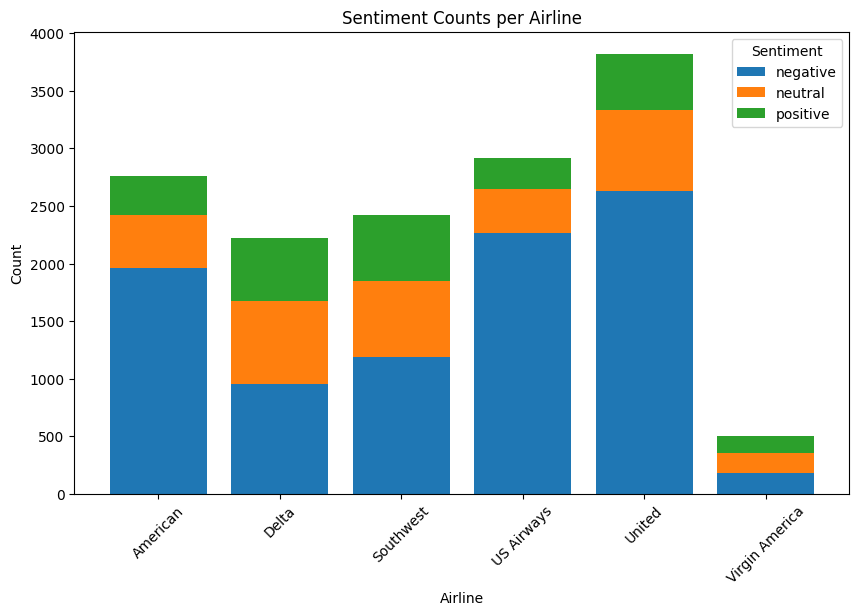

In [ ]:
# Define the index (rows/categories) and columns (the stacked segments)

categories = pivot_df.index
columns = pivot_df.columns

# Set up the figure size
plt.figure(figsize=(10, 6))

# Define the bottom values for stacking
bottom = [0] * len(categories)


# Iterate through each column in the pivot table to create the stacked bars
for col in columns:
    plt.bar(categories, pivot_df[col], bottom=bottom, label=col)
    bottom = bottom + pivot_df[col]  # Update the bottom for the next stack

# Add labels, title, and legend
plt.xlabel('Airline')
plt.ylabel('Count')
plt.title('Sentiment Counts per Airline')
plt.xticks(rotation=45)
plt.legend(title='Sentiment')

# Show the plot
plt.show()

#### Visualize the horizontal barplot of negative reasons

In [ ]:
# YOUR CODE HERE
dfNegativeTweets = dfTweetsHandy.filter(dfTweetsHandy['airline_sentiment'] == 'negative')
negative_reasons = dfNegativeTweets.groupby('negativereason').count()
negative_reasons.show()

+--------------------+-----+
|      negativereason|count|
+--------------------+-----+
|        Lost Luggage|  724|
|           longlines|  178|
|         Late Flight| 1665|
|     Damaged Luggage|   74|
|    Cancelled Flight|  847|
|Customer Service ...| 2910|
|Flight Attendant ...|  481|
|          Bad Flight|  580|
|          Can't Tell| 1190|
|Flight Booking Pr...|  529|
+--------------------+-----+



Text(0.5, 1.0, 'Tweet Count for Different Negative Reasons')

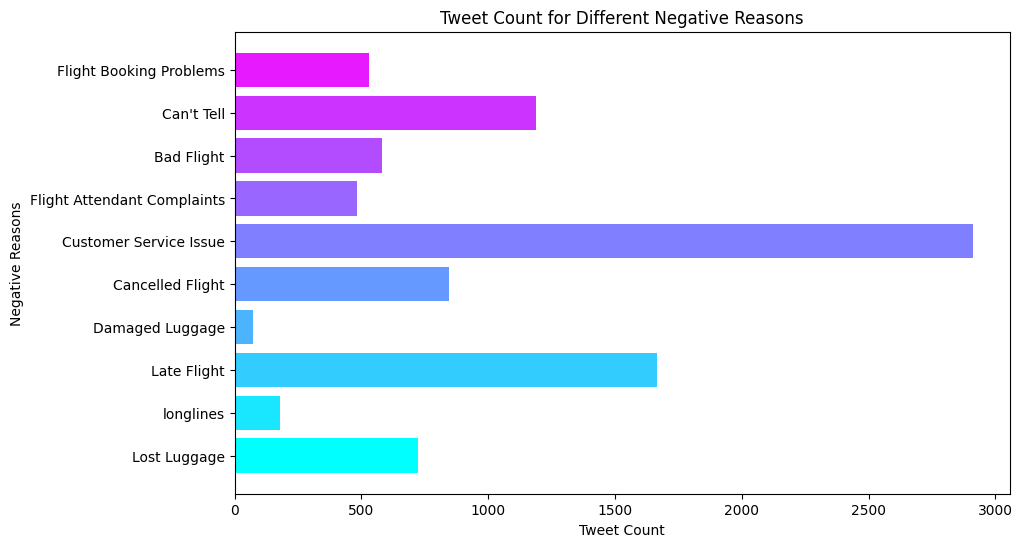

In [ ]:
# Convert the HandySpark DataFrame to pandas DataFrame
negative_reasons_counts_pd = negative_reasons.toPandas()

# Set the 'airline' column as the index for better labeling
negative_reasons_counts_pd.set_index('negativereason', inplace=True)

# Extract the sentiment labels and their counts
negativereasons = negative_reasons_counts_pd.index
counts = negative_reasons_counts_pd['count']

# Create a colormap and generate different colors for each bar
cmap = cm.get_cmap('cool')  # You can choose other colormaps like 'plasma', 'cool', etc.
colors = [cmap(i / len(counts)) for i in range(len(counts))]

# Create the horizontal bar plot
plt.figure(figsize=(10, 6))
plt.barh(negativereasons, counts, color=colors)
plt.xlabel('Tweet Count')
plt.ylabel('Negative Reasons')
plt.title('Tweet Count for Different Negative Reasons')

### Pre-processing (3 points)

#### Check the null values and drop the records where the text value is null

In [ ]:
dfTweetsHandy.describe()

HandyFrame[summary: string, tweet_id: string, airline_sentiment: string, airline_sentiment_confidence: string, negativereason: string, negativereason_confidence: string, airline: string, airline_sentiment_gold: string, name: string, negativereason_gold: string, retweet_count: string, text: string, tweet_coord: string, tweet_created: string, tweet_location: string, user_timezone: string]

In [ ]:
dfTweetsHandy.head(10)

[Row(tweet_id='570306133677760513', airline_sentiment='neutral', airline_sentiment_confidence='1.0', negativereason=None, negativereason_confidence=None, airline='Virgin America', airline_sentiment_gold=None, name='cairdin', negativereason_gold=None, retweet_count=0, text='@VirginAmerica What @dhepburn said.', tweet_coord=None, tweet_created='2015-02-24 11:35:52 -0800', tweet_location=None, user_timezone='Eastern Time (US & Canada)'),
 Row(tweet_id='570301130888122368', airline_sentiment='positive', airline_sentiment_confidence='0.3486', negativereason=None, negativereason_confidence='0.0', airline='Virgin America', airline_sentiment_gold=None, name='jnardino', negativereason_gold=None, retweet_count=0, text="@VirginAmerica plus you've added commercials to the experience... tacky.", tweet_coord=None, tweet_created='2015-02-24 11:15:59 -0800', tweet_location=None, user_timezone='Pacific Time (US & Canada)'),
 Row(tweet_id='570301083672813571', airline_sentiment='neutral', airline_sentim

In [ ]:
# Check for null values in each column of the HandySpark DataFrame
#null_counts = dfTweets.stats.nulls()
import pyspark.sql.functions as F

null_counts = dfTweets.select([F.count(F.when(F.isnull(c), c)).alias(c) for c in dfTweets.columns]).collect()[0].asDict()

# Display the result
print(null_counts)

{'tweet_id': 0, 'airline_sentiment': 155, 'airline_sentiment_confidence': 68, 'negativereason': 5573, 'negativereason_confidence': 4229, 'airline': 179, 'airline_sentiment_gold': 14788, 'name': 196, 'negativereason_gold': 14805, 'retweet_count': 205, 'text': 205, 'tweet_coord': 13768, 'tweet_created': 389, 'tweet_location': 5010, 'user_timezone': 5103}


There are 205 records with 'text' value as NULL.

In [ ]:
# Remove rows with NULL Value for text
dfTweetsNonNull = dfTweets.filter(dfTweets['text'].isNotNull())

In [ ]:
# Number of records in Spark dataframe
dfTweets.count()

14837

In [ ]:
dfTweetsNonNull.count()

14632

#### Fill the null values with 0 in all the columns except the target

The target should not be empty. Ensure that all features are integer type, convert if needed.

In [ ]:
# YOUR CODE HERE

#### Preprocessing and cleaning the tweets

* Convert the text to lower case
* Remove usernames, hashtags and links from the text (tweets)

In [ ]:
# YOUR CODE HERE
# Convert the text to lower case
from pyspark.sql.functions import lower, col
dfTweetsNonNull1 = dfTweetsNonNull.withColumn('processed_text', lower(col('text')))

In [ ]:
dfTweetsNonNull1.head()

Row(tweet_id='570306133677760513', airline_sentiment='neutral', airline_sentiment_confidence='1.0', negativereason=None, negativereason_confidence=None, airline='Virgin America', airline_sentiment_gold=None, name='cairdin', negativereason_gold=None, retweet_count=0, text='@VirginAmerica What @dhepburn said.', tweet_coord=None, tweet_created='2015-02-24 11:35:52 -0800', tweet_location=None, user_timezone='Eastern Time (US & Canada)', processed_text='@virginamerica what @dhepburn said.')

In [ ]:
# Remove usernames
dfTweetsNonNull2 = dfTweetsNonNull1.withColumn('processed_text', regexp_replace(col('processed_text'), r'@\w+', ''))

In [ ]:
dfTweetsNonNull2.head()

Row(tweet_id='570306133677760513', airline_sentiment='neutral', airline_sentiment_confidence='1.0', negativereason=None, negativereason_confidence=None, airline='Virgin America', airline_sentiment_gold=None, name='cairdin', negativereason_gold=None, retweet_count=0, text='@VirginAmerica What @dhepburn said.', tweet_coord=None, tweet_created='2015-02-24 11:35:52 -0800', tweet_location=None, user_timezone='Eastern Time (US & Canada)', processed_text=' what  said.')

#### Tokenize each sentence into words using nltk word tokenizer

In [ ]:
import nltk
from nltk.tokenize import word_tokenize
from pyspark.sql.functions import udf, col
from pyspark.sql.types import ArrayType, StringType

# Download the tokenizer data if you haven't done it before
nltk.download('punkt')

# Create a UDF for word_tokenize
word_tokenize_udf = udf(lambda text: word_tokenize(text), ArrayType(StringType()))

# Tokenize the 'text' column using the UDF and add it to a new column
dfTweetsNonNull3 = dfTweetsNonNull2.withColumn('tokenized_text', word_tokenize_udf(col('processed_text')))

remove_punctuation_udf = udf(lambda tokens: [word for word in tokens if word not in string.punctuation], ArrayType(StringType()))

# Remove punctuation from the tokenized text
dfTweetsNonNull3 = dfTweetsNonNull3.withColumn('tokenized_text', remove_punctuation_udf(col('tokenized_text')))





# Tokenize the 'text' column and add it to a new column
#dfTweetsNonNull2['tokenized_text'] = dfTweetsNonNull2['text'].apply(lambda x: word_tokenize(x))

# Display the updated DataFrame to verify
# import ace_tools as tools
# tools.display_dataframe_to_user(name="Tokenized Tweets", dataframe=dfTweetsNonNull2)


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [ ]:
dfTweetsNonNull3.head()

Row(tweet_id='570306133677760513', airline_sentiment='neutral', airline_sentiment_confidence='1.0', negativereason=None, negativereason_confidence=None, airline='Virgin America', airline_sentiment_gold=None, name='cairdin', negativereason_gold=None, retweet_count=0, text='@VirginAmerica What @dhepburn said.', tweet_coord=None, tweet_created='2015-02-24 11:35:52 -0800', tweet_location=None, user_timezone='Eastern Time (US & Canada)', processed_text=' what  said.', tokenized_text=['what', 'said'])

#### Remove the stopwords from tokenized words

In [ ]:
stop_words = set(stopwords.words('english'))
print(stop_words)

{'am', 'that', "doesn't", 'very', 'against', 'weren', 'up', 'why', 'couldn', 'wouldn', 'your', 'as', 'has', 'no', 'doesn', 'into', 'haven', 'mustn', 'to', 'those', 'the', 'now', 'i', 'off', 'these', 'then', 'few', 'such', 'too', 'hasn', 'will', 'by', 'other', 'during', 'itself', "mightn't", 'in', 'be', 'are', 'they', 'do', 'she', "hadn't", 'if', 'having', 'just', "isn't", "that'll", 'an', 'between', 'yours', 'only', 'above', "you'd", 'who', 'shouldn', 'here', "needn't", 'himself', 'when', 'he', 'did', 'about', 'at', 'hadn', 'before', 'ourselves', 'is', 'we', 'ma', 'once', 'again', 've', 'them', 'or', 'had', 'themselves', "shan't", "shouldn't", 'nor', 'same', "didn't", 'until', 'this', 'both', 'there', "it's", 'their', 'its', 'our', 'ours', "wouldn't", 'through', "mustn't", 'herself', 'his', 'd', 'where', 'under', 'hers', 'which', 'not', 'll', 'ain', 'most', 'a', 'you', 'shan', "don't", 're', 'didn', 'yourselves', 'have', 't', 'any', "you've", 'down', 'more', 'don', 'can', 'isn', 'needn

In [ ]:
# Remove stop_words from tokenized words
remove_stopwords_udf = udf(lambda tokens: [word for word in tokens if word not in stop_words], ArrayType(StringType()))
dfTweetsNonNull4 = dfTweetsNonNull3.withColumn('tokenized_text', remove_stopwords_udf(col('tokenized_text')))

In [ ]:
# YOUR CODE HERE
dfTweetsNonNull4.head()

Row(tweet_id='570306133677760513', airline_sentiment='neutral', airline_sentiment_confidence='1.0', negativereason=None, negativereason_confidence=None, airline='Virgin America', airline_sentiment_gold=None, name='cairdin', negativereason_gold=None, retweet_count=0, text='@VirginAmerica What @dhepburn said.', tweet_coord=None, tweet_created='2015-02-24 11:35:52 -0800', tweet_location=None, user_timezone='Eastern Time (US & Canada)', processed_text=' what  said.', tokenized_text=['said'])

#### Apply Lemmatization to the words

In [ ]:
# YOUR CODE HERE
# Apply lemmatization to the words
lemmatizer = WordNetLemmatizer()
lemmatize_udf = udf(lambda tokens: [lemmatizer.lemmatize(word) for word in tokens], ArrayType(StringType()))
dfTweetsNonNull5 = dfTweetsNonNull4.withColumn('tokenized_text', lemmatize_udf(col('tokenized_text')))



In [ ]:
dfTweetsNonNull5.head()

Row(tweet_id='570306133677760513', airline_sentiment='neutral', airline_sentiment_confidence='1.0', negativereason=None, negativereason_confidence=None, airline='Virgin America', airline_sentiment_gold=None, name='cairdin', negativereason_gold=None, retweet_count=0, text='@VirginAmerica What @dhepburn said.', tweet_coord=None, tweet_created='2015-02-24 11:35:52 -0800', tweet_location=None, user_timezone='Eastern Time (US & Canada)', processed_text=' what  said.', tokenized_text=['said'])

### Feature Extraction (3 points)

Create the useful features from the text column to train the model

For example:
* Length of the tweet
* No. of hashtags in the tweet starting with '#'
* No. of mentions in the tweet starting with '@'

Hint: create a new column for each of the above features

In [ ]:
# YOUR CODE HERE
# Add length of tweet as a feature
dfTweetsNonNull5 = dfTweetsNonNull5.withColumn('tweet_length', length(col('text')).astype('int'))

In [ ]:
dfTweetsNonNull5.head()

Row(tweet_id='570306133677760513', airline_sentiment='neutral', airline_sentiment_confidence='1.0', negativereason=None, negativereason_confidence=None, airline='Virgin America', airline_sentiment_gold=None, name='cairdin', negativereason_gold=None, retweet_count=0, text='@VirginAmerica What @dhepburn said.', tweet_coord=None, tweet_created='2015-02-24 11:35:52 -0800', tweet_location=None, user_timezone='Eastern Time (US & Canada)', processed_text=' what  said.', tokenized_text=['said'], tweet_length=35)

In [ ]:
# Add No. of hashtags in the tweet starting with '#'
num_hashtags = udf(lambda text: len(re.findall(r'#\w+', text)), IntegerType())
dfTweetsNonNull5 = dfTweetsNonNull5.withColumn('num_hashtags', num_hashtags(col('text')).astype('int'))

In [ ]:
# Add No. of mentions in the tweet starting with '@'
num_mentions = udf(lambda text: len(re.findall(r'@\w+', text)), IntegerType())
dfTweetsNonNull5 = dfTweetsNonNull5.withColumn('num_mentions', num_mentions(col('text')).astype('int'))

#### Get the features by applying CountVectorizer
CountVectorizer converts the list of tokens to vectors of token counts. See the [documentation](https://spark.apache.org/docs/latest/ml-features.html#countvectorizer) for details.

**We have removed @ as part of removing user names. Should we use text, processed_text or tokenized_text for feature extraction?❓**

In [ ]:
# fit a CountVectorizerModel from the corpus.
#cv = CountVectorizer(inputCol="tokenized_text", outputCol="count vectors", vocabSize=3, minDF=2.0)
cv = CountVectorizer(inputCol="tokenized_text", outputCol="count vectors")
cv_model = cv.fit(dfTweetsNonNull5)

result = cv_model.transform(dfTweetsNonNull5)
result.show(truncate=False)

+------------------+-----------------+----------------------------+--------------+-------------------------+--------------+----------------------+---------------+-------------------+-------------+--------------------------------------------------------------------------------------------------------------------------------------------+-----------+-------------------------+----------------------------+--------------------------+------------------------------------------------------------------------------------------------------------------------------+---------------------------------------------------------------------------------------------------------------------+------------+------------+------------+-------------------------------------------------------------------------------------------------------------------------------------------------+
|tweet_id          |airline_sentiment|airline_sentiment_confidence|negativereason|negativereason_confidence|airline       |airline_sentime

In [ ]:
dfTweetsNonNull6 = result

#### Encode the labels

Using the `udf` function encode the string values of *airline_sentiment* to integers.

In [ ]:
from pyspark.sql.types import IntegerType

def LabelEncoder(x):
    if x == 'positive':
        return 0
    elif x == 'negative':
        return 1
    return 2

# YOUR CODE HERE
# create udf to encode airline_sentiment to integers
label_encoder_udf = udf(LabelEncoder, IntegerType())

# Apply udf on airline_sentiment column
dfTweetsNonNull7 = dfTweetsNonNull6.withColumn('sentiment_label', label_encoder_udf(col('airline_sentiment')))


In [ ]:
dfTweetsNonNull7.head()

Row(tweet_id='570306133677760513', airline_sentiment='neutral', airline_sentiment_confidence='1.0', negativereason=None, negativereason_confidence=None, airline='Virgin America', airline_sentiment_gold=None, name='cairdin', negativereason_gold=None, retweet_count=0, text='@VirginAmerica What @dhepburn said.', tweet_coord=None, tweet_created='2015-02-24 11:35:52 -0800', tweet_location=None, user_timezone='Eastern Time (US & Canada)', processed_text=' what  said.', tokenized_text=['said'], tweet_length=35, num_hashtags=0, num_mentions=2, count vectors=SparseVector(15037, {136: 1.0}), sentiment_label=2)

### Train the classifier the evaluate (1 point)

#### Create vector assembler with the selected features to train the model

In [ ]:
# YOUR CODE HERE
# Create vector assembler with the selected features to train the model
featureassembler = VectorAssembler(inputCols=['count vectors', 'tweet_length', 'num_hashtags', 'num_mentions'], outputCol='features')

#### Arrange features and label and split them into train and test.

In [ ]:
# YOUR CODE HERE
# Arrange features and label and split them into train and test.
df_featured = featureassembler.transform(dfTweetsNonNull7)

In [ ]:
df_featured.head()

Row(tweet_id='570306133677760513', airline_sentiment='neutral', airline_sentiment_confidence='1.0', negativereason=None, negativereason_confidence=None, airline='Virgin America', airline_sentiment_gold=None, name='cairdin', negativereason_gold=None, retweet_count=0, text='@VirginAmerica What @dhepburn said.', tweet_coord=None, tweet_created='2015-02-24 11:35:52 -0800', tweet_location=None, user_timezone='Eastern Time (US & Canada)', processed_text=' what  said.', tokenized_text=['said'], tweet_length=35, num_hashtags=0, num_mentions=2, count vectors=SparseVector(15037, {136: 1.0}), sentiment_label=2, features=SparseVector(15040, {136: 1.0, 15037: 35.0, 15039: 2.0}))

In [ ]:
X=df_featured.select('features')
y=df_featured.select('sentiment_label')

In [ ]:
# Split into train and test
train_data, test_data = df_featured.randomSplit([0.7, 0.3])


#### Train the model with train data and make predictions on the test data

For classification of text data, implement NaiveBayes classifier. It is a probabilistic machine learning model.

For more information about **NaiveBayes Classifier**, click [here](https://spark.apache.org/docs/latest/ml-classification-regression.html#naive-bayes)

In [ ]:
nb = NaiveBayes(featuresCol='features', labelCol='sentiment_label')
# Fit the model with train data
model = nb.fit(train_data)

In [ ]:
# get the predictions
# YOUR CODE HERE
test_predict = model.transform(test_data)

In [ ]:
test_predict.head()

Row(tweet_id='567591480085463040', airline_sentiment='negative', airline_sentiment_confidence='1.0', negativereason='Late Flight', negativereason_confidence='0.34600000000000003', airline='United', airline_sentiment_gold=None, name='CPoutloud', negativereason_gold=None, retweet_count=0, text='@united yes. We waited in line for almost an hour to do so. Some passengers just left not wanting to wait past 1am.', tweet_coord=None, tweet_created='2015-02-16 23:48:48 -0800', tweet_location='Washington, DC', user_timezone=None, processed_text=' yes. we waited in line for almost an hour to do so. some passengers just left not wanting to wait past 1am.', tokenized_text=['yes', 'waited', 'line', 'almost', 'hour', 'passenger', 'left', 'wanting', 'wait', 'past', '1am'], tweet_length=115, num_hashtags=0, num_mentions=1, count vectors=SparseVector(15037, {6: 1.0, 59: 1.0, 102: 1.0, 108: 1.0, 118: 1.0, 139: 1.0, 264: 1.0, 373: 1.0, 429: 1.0, 2689: 1.0, 2958: 1.0}), sentiment_label=1, features=SparseVe

#### Evaluate the model and find the accuracy

Compare the labels and predictions and find how many are correct.

To find the accuracy, get the count of correct predictions from test data and divide by the total amount of test dataset.

**Hint:** convert the predictions dataframe to pandas and compare with labels

In [ ]:
# YOUR CODE HERE
# Evaluate the model
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

evaluator = MulticlassClassificationEvaluator(labelCol="sentiment_label", predictionCol="prediction", metricName="accuracy")
accuracy = evaluator.evaluate(test_predict)
print("Accuracy:", accuracy)

Accuracy: 0.7277535065532307


As a next phase of implementation, we will implement logistic regression model.

### Implementing logistic regression.

For more information about logistic regression, click upon this [button](https://spark.apache.org/docs/2.3.1/api/python/pyspark.ml.html#pyspark.ml.classification.LogisticRegression) to proceed to spark's documentation of logistic regression.

In [ ]:
# Importing the necessary libraries
from pyspark.ml.classification import LogisticRegression
import numpy
from numpy import allclose
from pyspark.ml.linalg import Vectors
from pyspark.ml.feature import StringIndexer
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

In [ ]:
# Create a features column using VectorAssembler with multiple input columns like 'rawFeatures', 'airline_sentiment_confidence', and others?
# YOUR CODE HERE

In [ ]:
# Create an object of stringindexer
# YOUR CODE HERE

In [ ]:
# Create output column for labels or target variable.
# YOUR CODE HERE

In [ ]:
# Split the data into train and test
# YOUR CODE HERE

In [ ]:
# Create a Logistic Regression model object with specified parameters like maxIter=20, regParam=0.3, and elasticNetParam=0
# YOUR CODE HERE

In [ ]:
# Fit a Logistic Regression model to the training dataset using the fit method on the train data
# YOUR CODE HERE

### Making predictions and evaluating the model

In [ ]:
# Generate predictions on the test dataset
# YOUR CODE HERE

In [ ]:
# Create a MulticlassClassificationEvaluator object to evaluate predictions using the "prediction" column
# YOUR CODE HERE

In [ ]:
# Calculate the accuracy of predictions using the evaluate method from the MulticlassClassificationEvaluator
# YOUR CODE HERE

In [ ]:
# Print accuracy
# YOUR CODE HERE

# Gradio Implementation (1 point)

In [ ]:
!pip -q install gradio

In [ ]:
import gradio as gr

### Making predictions using NaiveBayes

In [ ]:
def make_prediction_using_NaiveBayes(user_input):
  df1 = spark.createDataFrame([ (1, user_input)],['Id', 'UserTweet'])

  df1 = df1.withColumn('UserTweet',words(df1['UserTweet']))
  df1 = df1.withColumn("wordss", word_udf("UserTweet"))
  df1 = df1.withColumn("wordss", punct_udf1("wordss"))
  df1 = df1.withColumn("wordss", array_udf("wordss"))
  df1 = df1.withColumn("wordss", lem("wordss"))
  df1 = df1.withColumn("wordss", array_udf("wordss"))

  df1 = df1.withColumn('tweet_length', length(df1['UserTweet']).astype('int'))
  df1 = df1.withColumn('num_hashtags', num_hashtags(df1['UserTweet']).astype('int'))
  df1 = df1.withColumn('num_mentions', num_mentions(df1['UserTweet']).astype('int'))
  df1 = df1.withColumn('PunctCount',punctCount(df1['UserTweet']).astype('int'))
  df1 = df1.withColumn('typePunct',typePunct(df1['UserTweet']).astype('int'))
  make  = udf(lambda x : 0)
  df1 = df1.withColumn('negativereason_confidence',make(df1['UserTweet']).astype('int'))
  df1 = df1.withColumn('airline_sentiment_confidence',make(df1['UserTweet']).astype('int'))
  df1 = df1.withColumn('retweet_count',make(df1['UserTweet']).astype('int'))
  df1_featured = count_model.transform(df1)
  test_features = featureassembler.transform(df1_featured)
  test_predict = model.transform(test_features)
  df_res = test_predict.select('prediction').toPandas()
  pred = df_res.prediction.values[0]

  if pred == 0:
    return "Positive tweet!"
  elif pred == 1:
    return "Negative Tweet!"
  return "Neutral tweet"

In [ ]:
# Make a prediction using make_prediction_using_NaiveBayes for the text "It was a bad approach"
# YOUR CODE HERE

### Making predictions using LogisticRegression

In [ ]:
def make_prediction_using_LogReg(user_input):
  df1 = spark.createDataFrame([ (1, user_input)],['Id', 'UserTweet'])

  df1 = df1.withColumn('UserTweet',words(df1['UserTweet']))
  df1 = df1.withColumn("wordss", word_udf("UserTweet"))
  df1 = df1.withColumn("wordss", punct_udf1("wordss"))
  df1 = df1.withColumn("wordss", array_udf("wordss"))
  df1 = df1.withColumn("wordss", lem("wordss"))
  df1 = df1.withColumn("wordss", array_udf("wordss"))

  df1 = df1.withColumn('tweet_length', length(df1['UserTweet']).astype('int'))
  df1 = df1.withColumn('num_hashtags', num_hashtags(df1['UserTweet']).astype('int'))
  df1 = df1.withColumn('num_mentions', num_mentions(df1['UserTweet']).astype('int'))
  df1 = df1.withColumn('PunctCount',punctCount(df1['UserTweet']).astype('int'))
  df1 = df1.withColumn('typePunct',typePunct(df1['UserTweet']).astype('int'))
  make  = udf(lambda x : 0)
  df1 = df1.withColumn('negativereason_confidence',make(df1['UserTweet']).astype('int'))
  df1 = df1.withColumn('airline_sentiment_confidence',make(df1['UserTweet']).astype('int'))
  df1 = df1.withColumn('retweet_count',make(df1['UserTweet']).astype('int'))
  df1_featured = count_model.transform(df1)
  predictions = lrModel.transform(assembler.transform(df1_featured))
  df_res = predictions.select('prediction').toPandas()

  pred = df_res.prediction.values[0]

  if pred == 0:
    return "Positive tweet!"
  elif pred == 1:
    return "Negative Tweet!"
  return "Neutral tweet"

In [ ]:
# Make a prediction using make_prediction_using_LogReg "It was a bad approach"
# YOUR CODE HERE

### Launching Gradio application

Deployment is done for both the models:
1. Naive bayes
2. Logistic regression



Let's integrate all the above code snippets in the following code cell and run it with **Gradio interface**.

From the start (data loading step), place every code in make_prediction_using_NaiveBayes() including data preprocessing, feature extraction and model training.

**Similar procedure will be followed for logistic regression model deployment**
* In this case, the name of the application function created will be make_prediction_using_NaiveBayes()

* implement the above 2 functions which take one tweet input from user and returns the prediction using the trained model.

* use the same preprocessing techniques and features extraction used for train data on user input.

* user input can be captured from the textbox from **Gradio** app. Action is triggered when 'Submit' button is clicked and user input is classified using `make_prediction_using_NaiveBayes()` function.

* Selecting the Logist Regression tab in Gradio app, user input can be captured from the textbox. Action is triggered when 'Submit' button is clicked and user input is classified using `make_prediction_using_LogReg()` function.

For More information about Gradio, click [here](https://www.gradio.app/docs)

#### Start the app

Now that we have written our app, we can now start our app like we would have done if we were running it locally. But the caveat is to run it in the background so that if the following code cell finish running, our app will continue to run as a background process behind.

In [ ]:
# Launch a Gradio application with two tabbed interfaces for text classification, using Naive Bayes and Logistic Regression models
# YOUR CODE HERE